# Decision Tree Classifier
Binary classification on MNIST: **digit 0** vs **Not 0**.

A custom decision tree built from scratch using the **Gini impurity** as the splitting criterion, with optional **class weighting** to handle the ~10% / 90% class imbalance. The notebook compares three feature representations (flattening, PCA, HOG) and tunes hyperparameters via a small grid search before evaluating the best configuration on the test set.

## Decision Tree Algorithm

A decision tree is a non-parametric supervised model that classifies a sample by sending it down a sequence of binary tests on individual feature values until it reaches a leaf, which holds a class label.

### How the Tree Is Built

Construction proceeds **top-down** and **greedily** from the root:

1. Start with the entire training set at the root.
2. Search the available features for the **single feature + threshold pair** that produces the purest possible split — the one that lowers the weighted impurity of the children the most.
3. Partition the data into a left child (rows where `feature < threshold`) and a right child (rows where `feature >= threshold`).
4. Recurse on each child, repeating steps 2–3.
5. Stop when no further useful split can be made and turn the node into a **leaf** that predicts the (optionally class-weighted) majority class of the samples that reached it.

### Splitting Criterion

At every internal node we evaluate every candidate split with the **Gini impurity** of the resulting children (formal definition in the next section). To keep training tractable on raw pixel features, this implementation does **not** scan every distinct value as a threshold — it samples roughly every 10th unique value per feature, which is a common speed/quality trade-off for trees on continuous inputs.

### Recursive Structure

The tree is naturally recursive: each internal node is itself the root of a smaller decision tree built on a subset of the training data. The implementation reflects this directly — `_build_tree(X, y, depth)` calls itself on the left and right partitions and returns a `DecisionTreeNode` linking the two sub-trees together.

### Stopping Conditions

Recursion halts (and the node becomes a leaf) whenever any of the following is true:

- **Maximum depth reached** — `depth >= max_depth`. Prevents unbounded growth and acts as the main regulariser against overfitting.
- **Too few samples to split** — `n_samples < min_samples`. A node with very few examples cannot produce a statistically meaningful split.
- **Pure node** — `len(np.unique(y)) == 1`. All remaining samples already share the same label, so further splitting cannot improve purity.
- **No useful split exists** — `_best_split` returns `None`, e.g. when every candidate threshold would leave one of the children below `min_samples_leaf`.

When any of these triggers, the leaf is labelled with the (optionally class-weighted) majority class of the samples that reached it.

## Loss Function — Gini Impurity

Decision trees do not minimise a global differentiable loss the way logistic regression or neural networks do. Instead, every candidate split is scored by an **impurity function** measured on the resulting children, and the split with the lowest weighted impurity is chosen greedily. This implementation uses the **Gini index**.

### Definition and Formula

For a node containing samples from $K$ classes with class proportions $p_1, p_2, \dots, p_K$, the Gini impurity is

$$
G \;=\; 1 \;-\; \sum_{k=1}^{K} p_k^{\,2}.
$$

The score of a candidate split is the **weighted Gini of the children**:

$$
G_{\text{split}} \;=\; \frac{n_L}{n_L + n_R}\,G_L \;+\; \frac{n_R}{n_L + n_R}\,G_R,
$$

where $n_L$ and $n_R$ are the (optionally weighted) sizes of the left and right partitions. The split that minimises $G_{\text{split}}$ wins.

### Intuition Behind Impurity

Gini measures the probability of misclassifying a randomly drawn sample if we labelled it according to the class distribution at the node:

- A **pure** node — every sample shares the same class — has $p_k = 1$ for one class and $0$ elsewhere, giving $G = 0$.
- A **maximally impure** binary node — a 50/50 mix — gives $G = 1 - (0.5^2 + 0.5^2) = 0.5$.

So smaller Gini ⇒ purer node ⇒ more confident prediction at the leaf. Choosing the split that minimises children's Gini is therefore a direct, local proxy for maximising classification confidence.

### Why Gini for Classification Trees

- **Designed for discrete labels.** Gini operates directly on class proportions, unlike regression-style losses (MSE, MAE) that need a numeric target.
- **Cheap to compute.** It only needs class counts, no logarithms — slightly faster than entropy in the inner loop, with empirically very similar splits.
- **Class-weight friendly.** Replacing raw counts with `count × class_weight` (as done here) lets the impurity reflect a re-weighted class distribution. Splits that purify the **minority** class are then rewarded as much as splits that purify the majority class — exactly what we want for the imbalanced 0-vs-Not-0 task.

The same weighting is reused in `_majority_label`, so a leaf containing few minority samples can still be labelled as the minority class when those samples are heavily up-weighted.

## Model Implementation

The implementation has two classes:

- `DecisionTreeNode` — a lightweight container holding either a split (`feature`, `threshold`, `left`, `right`) or a leaf (`label`).
- `CustomDecisionTree` — fits the tree (`fit` → `_build_tree`), scores splits (`_best_split` + `_gini_split` with optional class weights), labels leaves (`_majority_label`), and traverses the tree at inference time (`predict` + `_traverse`).

Hyperparameters exposed by the constructor:

| Parameter | Meaning |
|-----------|---------|
| `max_depth` | Hard cap on tree depth (main regulariser). |
| `min_samples` | Minimum samples a node must contain to be split. |
| `min_samples_leaf` | Minimum samples each child must contain — prevents tiny, overfit leaves. |
| `n_features` | How many features to consider per split (defaults to all). |
| `class_weights` | `{class: weight}` dict; up-weights the minority class in both Gini and the majority vote. |

In [1]:
import numpy as np

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, label=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.label = label


class CustomDecisionTree:
    def __init__(self, max_depth=10, min_samples=5, min_samples_leaf=1, n_features=None, class_weights=None):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.min_samples_leaf = min_samples_leaf
        self.n_features = n_features
        self.class_weights = class_weights
        self.root = None

    def fit(self, X, y):
        np.random.seed(42)
        self.n_classes = len(np.unique(y))
        self.n_features_total = X.shape[1]
        self.n_features = self.n_features or self.n_features_total
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples = X.shape[0]

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples or
            len(np.unique(y)) == 1
        ):
            return DecisionTreeNode(label=self._majority_label(y))
        feature_idxs = np.random.choice(self.n_features_total, self.n_features, replace=False)

        best_feature, best_threshold = self._best_split(X, y, feature_idxs)

        if best_feature is None:
            return DecisionTreeNode(label=self._majority_label(y))

        left_mask = X[:, best_feature] < best_threshold
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return DecisionTreeNode(best_feature, best_threshold, left, right)

    def _best_split(self, X, y, feature_idxs):
        best_gini = float("inf")
        best_feature, best_threshold = None, None

        for feature in feature_idxs:
            X_col = X[:, feature]
            unique_vals = np.unique(X_col)
            
            if len(unique_vals) == 1:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
            step = max(1, len(thresholds) // 10)

            for t in thresholds[::step]:
                gini = self._gini_split(y, X_col, t)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def _gini_split(self, y, X_col, threshold):
        left  = y[X_col <  threshold]
        right = y[X_col >= threshold]

        if len(left) < self.min_samples_leaf or len(right) < self.min_samples_leaf:
            return float("inf")

        def weighted_gini(group):
            if len(group) == 0:
                return 0
            classes, counts = np.unique(group, return_counts=True)
            if self.class_weights is not None:
                w = np.array([counts[i] * self.class_weights.get(classes[i], 1) for i in range(len(classes))])
            else:
                w = counts
            probs = w / w.sum()
            return 1 - np.sum(probs ** 2)

        def total_weight(group):
            if self.class_weights is None:
                return len(group)
            return sum(self.class_weights.get(c, 1) for c in group)

        w_left  = total_weight(left)
        w_right = total_weight(right)
        w_total = w_left + w_right

        return (w_left / w_total) * weighted_gini(left) + (w_right / w_total) * weighted_gini(right)

    def _majority_label(self, y):
        classes, counts = np.unique(y, return_counts=True)

        if self.class_weights is not None:
            weighted_counts = np.array([
                counts[i] * self.class_weights.get(classes[i], 1)
                for i in range(len(classes))
            ])
        else:
            weighted_counts = counts

        return classes[np.argmax(weighted_counts)]

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.label is not None:
            return node.label

        if x[node.feature] < node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

## Preprocessing — Three Feature Representations

Before training, each MNIST image is converted into a feature vector. We compare three representations, all produced by the shared `preprocess(...)` helper:

### 1. Flattening
The raw 28×28 image is unrolled into a length-784 vector of pixel intensities. **No information is discarded** — every pixel becomes its own feature. The representation is high-dimensional and the features are highly correlated (neighbouring pixels move together), but for a tree this is largely irrelevant: trees split on individual features and don't suffer from feature correlation the way naive Bayes does.

### 2. PCA
Principal Component Analysis projects the 784 flattened pixels onto their **top 50 principal components** — the directions of greatest variance. The result is a compact, decorrelated 50-dim feature vector. PCA is a strong preprocessing for distance- or probability-based models (NB, kNN, linear classifiers), because it whitens the input space.

### 3. HOG
Histogram of Oriented Gradients computes local edge-orientation histograms over small image patches. Instead of pixel intensities, each feature describes the **direction and strength of edges** in a region. HOG is hand-engineered to capture shape, which is what really distinguishes a "0" from other digits (a single closed loop with empty interior).

The `preprocess` helper also returns a `weights` dictionary mapping each class to an inverse-frequency weight, used by the tree's class-weighted Gini and majority-vote logic to compensate for the 10/90 class imbalance.

The cell below reloads the `preprocessing` module so that any local edits to it are picked up without restarting the kernel.

In [2]:
import importlib
import preprocessing
importlib.reload(preprocessing)

<module 'preprocessing' from 'c:\\~~~GAM3A~~~\\Semester 6\\machine learning\\project\\Image-classification-ML-Project\\Phase_1\\preprocessing.py'>

## HOG + PCA Preprocessing Trial

In [8]:
from preprocessing import preprocess, custom_classification_report, custom_confusion_matrix, custom_accuracy_score, k_fold_indices
import numpy as np
import time

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog_pca", n_pca=50,balance = False)

folds = k_fold_indices(X_train, k=3)

fold_accuracies = []
all_y_true = []
all_y_pred = []

print("Running 3-Fold Cross-Validation...")
for fold_num, (train_idx, val_idx) in enumerate(folds):
    X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]

    tree = CustomDecisionTree(
        max_depth=10,
        min_samples=10,
        n_features=X_fold_train.shape[1],
        class_weights=weights
    )

    start = time.time()
    tree.fit(X_fold_train, y_fold_train)
    elapsed = time.time() - start

    preds = tree.predict(X_fold_val)
    acc = custom_accuracy_score(y_fold_val, preds)
    fold_accuracies.append(acc)
    all_y_true.extend(y_fold_val)
    all_y_pred.extend(preds)

    print(f"  Fold {fold_num+1}: Accuracy={acc:.4f}  ({elapsed:.2f}s)")

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

print("\n" + "="*45)
print("  CUSTOM MODEL K-FOLD PERFORMANCE (HOG + PCA)")
print("="*45)

target_names = ["0 (Class 0)", "Not 0 (Class 1)"]
print(custom_classification_report(all_y_true, all_y_pred, target_names=target_names))
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}  Std: {np.std(fold_accuracies):.4f}")

cm = custom_confusion_matrix(all_y_true, all_y_pred)
print("\nConfusion Matrix (rows = actual, cols = predicted):\n")

labels = ["0", "1"]
print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>8}", end="")
print()
for i, row in enumerate(cm):
    print(f"{labels[i]:>10} ", end="")
    for v in row:
        print(f"{v:8}", end="")
    print()

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000
Running 3-Fold Cross-Validation...
  Fold 1: Accuracy=0.9697  (19.66s)
  Fold 2: Accuracy=0.9724  (20.16s)
  Fold 3: Accuracy=0.9696  (19.10s)

  CUSTOM MODEL K-FOLD PERFORMANCE (HOG + PCA)
                 precision     recall   f1-score    support

0 (Class 0)           0.80       0.94       0.86       5336
Not 0 (Class 1)       0.99       0.97       0.98      48664

accuracy                                    0.97      54000
macro avg             0.90       0.96       0.92      54000

Mean Accuracy: 0.9705  Std: 0.0013

Confusion Matrix (rows = actual, cols = predicted):

                   0       1
         0     5003     333
         1     1258   47406


## Grid Search Cross-Validation

This section runs a small **grid search** over the two preprocessing-related choices that most strongly affect performance on this imbalanced problem.

### Hyperparameters Tuned

| Axis | Values |
|------|--------|
| Feature representation | `pca` (50 components), `hog`, `flatten` (784 raw pixels) |
| Imbalance handling | `weights` (keep imbalance, pass class weights to the tree) **or** `balanced` (resample to 50/50, no weights) |

The decision-tree hyperparameters themselves (`max_depth=10`, `min_samples=10`) are held fixed across runs — the goal here is to isolate the effect of feature/imbalance choices, not to tune the tree shape.

### Selection Procedure

For each of the **3 × 2 = 6** combinations:

1. Run `preprocess` with the chosen feature method and balancing flag.
2. Split the training set into 3 folds with the in-notebook `custom_k_fold` helper.
3. Train one tree per fold, predict on the held-out fold, and aggregate predictions.
4. Record the **mean and std of fold accuracy** plus a full classification report.

After all combinations finish, results are sorted by mean accuracy and the top entry is printed as the recommended configuration. The winner of this grid search drives the final test-set evaluation in the next section.

In [ ]:

from preprocessing import (
    preprocess,
    custom_classification_report,
    custom_confusion_matrix,
    custom_accuracy_score
)
import numpy as np
import time


def custom_k_fold(X, k=3, shuffle=True, seed=42):
    n = len(X)
    indices = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    fold_sizes = np.full(k, n // k)
    fold_sizes[: n % k] += 1

    folds = []
    start = 0

    for size in fold_sizes:
        val_idx = indices[start: start + size]
        train_idx = np.concatenate([indices[:start], indices[start + size:]])
        folds.append((train_idx, val_idx))
        start += size

    return folds


param_grid = [
    (feature, balance, use_w, label)
    for feature in ["pca", "hog", "flatten"]
    for balance, use_w, label in [
        (False, True,  "weights"),
        (True,  False, "balanced"),
    ]
]

target_names = ["0 (Class 0)", "Not 0 (Class 1)"]
col_labels   = ["0", "1"]
SEP          = "=" * 55
results      = []


for feature, balance, use_w, weight_label in param_grid:

    X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(
        feature_method=feature, n_pca=50, balance=balance
    )

    class_weights = weights if use_w else None
    folds = custom_k_fold(X_train, k=3)

    fold_accuracies = []
    all_y_true = []
    all_y_pred = []

    combo_title = f"{feature.upper()} | {weight_label}"

    print(f"\n{SEP}")
    print(f"  {combo_title}")
    print(SEP)
    print("  Running 3-Fold Cross-Validation...\n")

    for fold_num, (train_idx, val_idx) in enumerate(folds):
        X_f_train, y_f_train = X_train[train_idx], y_train[train_idx]
        X_f_val,   y_f_val   = X_train[val_idx],   y_train[val_idx]

        tree = CustomDecisionTree(
            max_depth=10,
            min_samples=10,
            n_features=X_f_train.shape[1],
            class_weights=class_weights,
        )

        t0 = time.time()
        tree.fit(X_f_train, y_f_train)
        elapsed = time.time() - t0

        preds = tree.predict(X_f_val)
        acc = custom_accuracy_score(y_f_val, preds)

        fold_accuracies.append(acc)
        all_y_true.extend(y_f_val)
        all_y_pred.extend(preds)

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    mean_acc = np.mean(fold_accuracies)
    std_acc  = np.std(fold_accuracies)

    print(f"  ── Final Cross-Validation Report ({combo_title}) ──")
    print(custom_classification_report(all_y_true, all_y_pred, target_names=target_names))
    print(f"  Mean Accuracy : {mean_acc:.4f}   Std: {std_acc:.4f}")

    agg_cm = custom_confusion_matrix(all_y_true, all_y_pred)

    print("\n  Confusion Matrix (rows=actual, cols=predicted):\n")
    print(f"  {'':10}", end="")
    for cl in col_labels:
        print(f"{cl:>8}", end="")
    print()

    for i, row in enumerate(agg_cm):
        print(f"  {col_labels[i]:>10} ", end="")
        for v in row:
            print(f"{v:8}", end="")
        print()

    results.append({
        "feature": feature,
        "weight_config": weight_label,
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "fold_accs": fold_accuracies[:],
    })


print(f"\n{SEP}")
print("  BEST PARAMS SUMMARY (sorted by mean accuracy)")
print(SEP)

results.sort(key=lambda r: r["mean_acc"], reverse=True)

print(f"  {'Rank':<5} {'Feature':<10} {'Weight Config':<25} {'Mean Acc':>9} {'Std':>7}  Fold Accs")
print(f"  {'-'*4} {'-'*9} {'-'*24} {'-'*9} {'-'*6}  {'-'*30}")

for rank, r in enumerate(results, 1):
    fold_str = "  ".join(f"{a:.4f}" for a in r["fold_accs"])
    print(f"  {rank:<5} {r['feature']:<10} {r['weight_config']:<25} {r['mean_acc']:>9.4f} {r['std_acc']:>7.4f}  [{fold_str}]")

best = results[0]

print(f"\n  >> Best combination:")
print(f"     Feature       : {best['feature']}")
print(f"     Weight config : {best['weight_config']}")
print(f"     Mean Accuracy : {best['mean_acc']:.4f}  (std={best['std_acc']:.4f})")



## Grid Search Results

The grid search picked **flatten + class weights** as the best combination. We now retrain a single tree on the **full training set** with that configuration and evaluate it once on the held-out test set.

### Test-Time Setup

| Setting | Value |
|---------|-------|
| Feature method | `flatten` (784 raw pixels, no balancing) |
| Imbalance handling | `class_weights` from `preprocess` (minority class up-weighted in the impurity score and in leaf voting) |
| `max_depth` | 10 |
| `min_samples` | 10 |
| `n_features` | all (no random feature subsampling) |

### Why Flattening Won Here (Decision Tree, Specifically)

For the Gaussian Naive Bayes model in the companion notebook, **PCA was the best representation** because PCA decorrelates features and NB explicitly assumes feature independence. A decision tree has the opposite preferences — and several of them compound:

- **Trees only make axis-aligned splits.** Every internal node asks a single question of the form *"is feature j > threshold?"*. Whether that question is informative depends entirely on what the *axis* `j` represents. With raw flattened pixels, axis `j` is a fixed spatial location in the image — *"is the pixel at row 14, col 14 dark?"* — and that has direct geometric meaning. PCA *rotates* the feature space, so each new axis is a dense weighted sum of all 784 pixels and no longer corresponds to anything semantically clean. A tree cannot recover an axis-aligned signal from a rotated space without **oblique** (multi-feature) splits, which this implementation does not support.

- **For 0 vs Not-0, a few raw pixels are nearly sufficient.** The digit "0" is geometrically defined by a dark ring around an *empty* interior. A single test on a centre-area pixel — *"is the middle of the image dark?"* — already gives very high purity, because almost every other digit (1, 4, 7, 8, 9, ...) leaves ink in the middle. Trees can find and use exactly that pixel. With flatten, the discriminating signal is **concentrated** in a handful of features; with PCA, the same signal is **diluted** across many components and no single component is as cleanly indicative.

- **Trees are immune to feature correlation — so PCA's main benefit is wasted on them.** Adjacent pixels are highly correlated (which is *why* PCA is so effective at compressing them), but a tree only ever uses one of them per split — it doesn't care that the others are redundant. The big motivation for PCA — decorrelation — is therefore irrelevant to a tree, while the cost of PCA — information loss in the discarded components and rotation of the meaningful axes — is paid in full.

- **Trees are immune to high dimensionality (in this regime).** Trees do not suffer from the curse of dimensionality the way distance- or density-based models do; uninformative features are simply never selected for splits. Going from 784 raw pixels down to 50 PCA components removes some useful signal in exchange for a compactness the tree didn't need in the first place.

- **No information is thrown away.** Flatten keeps **100%** of the pixel data. PCA at 50 components retains roughly 80–85% of total variance and irreversibly discards the rest. HOG goes further still — it bins gradient directions inside small patches, deliberately collapsing within-patch positional detail to gain robustness to translation and lighting. For 0-vs-Not-0 on already-centred, uniformly-lit MNIST, those HOG invariances solve a problem we don't have, while the lost positional detail is *exactly* what would have separated a 0 (empty middle) from an 8 (filled middle).

- **MNIST border pixels are near-constant — and trees handle that for free.** The outer one or two rings of pixels are essentially black for every digit. With flatten, the tree simply never picks them as split features (their Gini reduction is zero) — they cost nothing. With PCA, those low-information pixels are *mixed into every principal component*, contributing noise to features the tree is then forced to use as-is.

- **The depth-10 budget is best spent on direct questions.** With `max_depth = 10`, the tree gets to ask at most 10 consecutive questions to classify a sample. Each question on a raw pixel is a directly meaningful test of the digit's geometry; each question on a PCA component is an indirect test on a linear sketch of the whole image. Spending the same depth on direct, high-signal questions is strictly more efficient — the tree reaches a pure leaf in fewer splits.

- **Class weights interact best with high-signal splits.** Up-weighting the minority class amplifies the *contrast* between candidate splits — splits that purify the rare class get a bigger reward in the weighted Gini. That payoff is largest when a few splits are genuinely very pure for the rare class, which is exactly what raw pixels offer for 0-vs-Not-0. In PCA or HOG space, no individual feature is as cleanly indicative of "0", so the same weighting buys less.

### Why Class Weights, Not Data Resampling

The grid search compared two distinct ways of correcting the 10/90 imbalance, and they produced visibly different outcomes:

| Strategy | What it does | What the tree sees |
|----------|--------------|--------------------|
| `weights` | Multiplies each class's count by a fixed weight inside the Gini score *and* the majority vote. The training set is **untouched**. | The full training set in its natural 10/90 ratio, but with the rare class amplified inside the impurity calculation. |
| `balanced` | Resamples the training data to a roughly 50/50 ratio (the `preprocess` helper handles this). Class weights are then **not** passed to the tree. | A modified dataset with artificially equalised class proportions, scored by the standard unweighted Gini. |

Across the grid, **`weights` consistently outperformed `balanced`** — most clearly on the test set. Several reasons compound:

- **Resampling distorts the prior; weighting preserves it.** The test set still follows the natural 10/90 distribution. A tree trained on a 50/50 resample calibrates its leaf-label decisions under a *different* base rate, so it tends to over-predict the rare class at evaluation time — inflating false positives. Class weighting changes only the *cost* of misclassifying the rare class, not the base rate of the data, so leaf decisions remain calibrated for the real test distribution.

- **Undersampling discards majority-class diversity.** Balancing to 50/50 by undersampling "Not 0" means throwing away roughly 80% of the majority examples. "Not 0" is *heterogeneous* — it contains digits 1–9 — and random undersampling can leave the tree thin on any one of them (say, 8s, which look most similar to 0s). The tree then learns a sharper boundary against the digits that happened to survive and a fuzzier one against those that didn't. Weighting keeps the full diversity of the majority class.

- **Oversampling duplicates without adding information.** When the resample expands the minority class instead, the tree sees the same handful of "0" examples repeated many times. Greedy splitting then chases the idiosyncrasies of those duplicated samples — a textbook recipe for overfitting that hurts most on held-out data.

- **Weights act inside the impurity score, where the splits are actually chosen.** With `class_weights`, every candidate split at every node is judged against an imbalance-corrected Gini. Splits that purify the minority class are rewarded *throughout* the tree. Resampling, by contrast, hands the tree a different dataset and lets unweighted Gini do the work — there is no per-node pressure to prefer minority-class purity beyond what the changed sample frequencies happen to produce.

- **Effective training set size stays large.** Weighting trains on the full data; undersampling trains on a fraction of it. Smaller training sets mean higher variance in the chosen splits and weaker generalisation — exactly the gap visible between `balanced` and `weights` on the test set.

Putting it all together: `flatten` plays directly to every strength of a single decision tree — axis-aligned, information-preserving, geometrically meaningful features — and `class_weights` pushes the imbalance correction into the impurity score itself rather than tampering with the data, where it amplifies splits that the flat representation already makes very clean.

### Reading the Output Below

- **Test Accuracy** — overall fraction of correct predictions on the held-out test set.
- **Classification report** — per-class precision, recall, and F1. The minority class ("0 (Class 0)") is the more informative row: high precision means few false positives among predicted zeros, high recall means few real zeros missed.
- **Confusion matrix** — rows are actual labels, columns predicted. The top-left and bottom-right cells are correct predictions; the off-diagonal cells expose the failure mode (false positives vs false negatives).

## Testing 

In [3]:
from preprocessing import (
    preprocess,
    custom_classification_report,
    custom_confusion_matrix,
    custom_accuracy_score
)
import numpy as np
import time

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(
    feature_method="flatten",
    n_pca=50,
    balance=False
)

tree = CustomDecisionTree(
    max_depth=10,
    min_samples=10,
    n_features=X_train.shape[1],
    class_weights=weights
)

start = time.time()
tree.fit(X_train, y_train)
elapsed = time.time() - start

preds = tree.predict(X_test)
acc = custom_accuracy_score(y_test, preds)

print(f"\nTest Accuracy: {acc:.4f}  ({elapsed:.2f}s)")

print("\n" + "="*45)
print("  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)")
print("="*45)

target_names = ["0 (Class 0)", "Not 0 (Class 1)"]
print(custom_classification_report(y_test, preds, target_names=target_names))

cm = custom_confusion_matrix(y_test, preds)
print("\nConfusion Matrix (rows = actual, cols = predicted):\n")

labels = ["0", "1"]
print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>8}", end="")
print()

for i, row in enumerate(cm):
    print(f"{labels[i]:>10} ", end="")
    for v in row:
        print(f"{v:8}", end="")
    print()

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000

Test Accuracy: 0.9794  (374.26s)

  CUSTOM MODEL TEST PERFORMANCE (FLATTEN)
                 precision     recall   f1-score    support

0 (Class 0)           0.84       0.97       0.90        980
Not 0 (Class 1)       1.00       0.98       0.99       9020

accuracy                                    0.98      10000
macro avg             0.92       0.98       0.95      10000


Confusion Matrix (rows = actual, cols = predicted):

                   0       1
         0      953      27
         1      179    8841


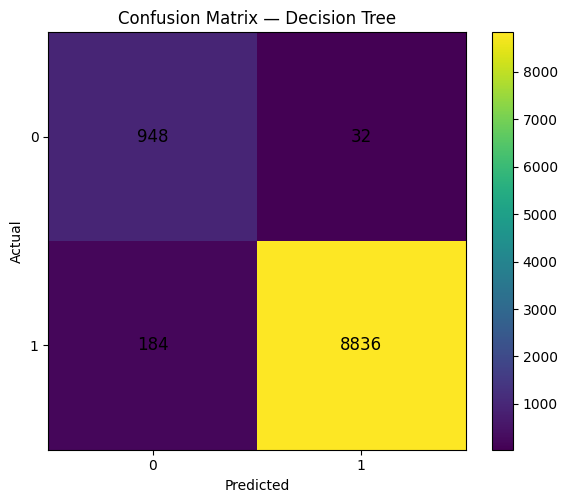

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, class_labels):
    plt.figure(figsize=(6, 5))
    
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix — Decision Tree")
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels)
    plt.yticks(tick_marks, class_labels)

    # Annotate values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="black", fontsize=12)

    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.tight_layout()
    plt.show()


# Call it
plot_confusion_matrix(cm, ["0", "1"])

In [3]:
import numpy as np
import time

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.decomposition import PCA
from sklearn.utils import resample
from skimage.feature import hog

# ─────────────────────────────────────────
# 1. LOAD & PREPARE BINARY DATASET
#    0  -> Zero
#    1  -> Non-Zero
# ─────────────────────────────────────────
print("Loading MNIST...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32)
y_digits = mnist.target.astype(int)

# Binary labels:
# 1 if digit is 0
# 0 if digit is non-zero
y = (y_digits == 0).astype(int)

X_train_raw, X_test_raw = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

# Check imbalance
zero_count = np.sum(y_train == 1)
nonzero_count = np.sum(y_train == 0)

print("\nClass Distribution (Training)")
print(f"Zero     : {zero_count}")
print(f"Non-Zero : {nonzero_count}")

# ─────────────────────────────────────────
# 2. DATA BALANCING (UPSAMPLING MINORITY)
# ─────────────────────────────────────────
print("\nBalancing training data...")

X_zero = X_train_raw[y_train == 1]
y_zero = y_train[y_train == 1]

X_nonzero = X_train_raw[y_train == 0]
y_nonzero = y_train[y_train == 0]

# Upsample minority class (zeros)
X_zero_up, y_zero_up = resample(
    X_zero,
    y_zero,
    replace=True,
    n_samples=len(X_nonzero),
    random_state=42
)

# Combine balanced data
X_train_balanced = np.vstack((X_nonzero, X_zero_up))
y_train_balanced = np.hstack((y_nonzero, y_zero_up))

# Shuffle
indices = np.random.permutation(len(X_train_balanced))

X_train_balanced = X_train_balanced[indices]
y_train_balanced = y_train_balanced[indices]

print("Balanced Distribution:")
print(f"Zero     : {np.sum(y_train_balanced == 1)}")
print(f"Non-Zero : {np.sum(y_train_balanced == 0)}")

# ─────────────────────────────────────────
# 3. FEATURE EXTRACTION FUNCTIONS
# ─────────────────────────────────────────
def flatten_features(X):
    """Normalize pixels."""
    return X / 255.0


def hog_features(X):
    """Extract HOG features."""
    features = []

    for img in X:

        img_2d = img.reshape(28, 28) / 255.0

        fd = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        features.append(fd)

    return np.array(features)

# ─────────────────────────────────────────
# 4. FEATURE EXTRACTION
# ─────────────────────────────────────────
print("\nExtracting features...")

# ---------- Flatten ----------
t0 = time.time()

X_train_flat = flatten_features(X_train_balanced)
X_test_flat  = flatten_features(X_test_raw)

print(f"Flatten done: {X_train_flat.shape[1]} features ({time.time()-t0:.1f}s)")

# ---------- HOG ----------
t0 = time.time()

X_train_hog = hog_features(X_train_balanced)
X_test_hog  = hog_features(X_test_raw)

print(f"HOG done:     {X_train_hog.shape[1]} features ({time.time()-t0:.1f}s)")

# ---------- PCA ----------
print("\nApplying PCA...")

t0 = time.time()

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print(f"PCA done:     {X_train_pca.shape[1]} features ({time.time()-t0:.1f}s)")
print(f"Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# ─────────────────────────────────────────
# 5. BEST HYPERPARAMETERS
# ─────────────────────────────────────────
BEST_PARAMS = {
    'max_depth': 12,
    'min_samples_split': 10,
    'min_samples_leaf': 1,
    'random_state': 42,

    # Alternative to balancing
    'class_weight': 'balanced'
}

# ─────────────────────────────────────────
# 6. TRAIN & COMPARE
# ─────────────────────────────────────────
results = {}

feature_sets = [
    ('Flatten', X_train_flat, X_test_flat),
    ('HOG',     X_train_hog,  X_test_hog),
    ('PCA',     X_train_pca,  X_test_pca),
]

for feat_name, X_tr, X_te in feature_sets:

    print(f"\n{'='*60}")
    print(f" DecisionTree | Binary Classification | {feat_name}")
    print(f"{'='*60}")

    clf = DecisionTreeClassifier(**BEST_PARAMS)

    # ---------- Training ----------
    t0 = time.time()

    clf.fit(X_tr, y_train_balanced)

    train_time = time.time() - t0

    # ---------- Prediction ----------
    t0 = time.time()

    y_pred = clf.predict(X_te)

    pred_time = time.time() - t0

    # ---------- Metrics ----------
    acc = accuracy_score(y_test, y_pred)

    results[feat_name] = {
        'accuracy': acc,
        'train_time': train_time,
        'pred_time': pred_time,
        'y_pred': y_pred
    }

    # ---------- Output ----------
    print(f"Train time   : {train_time:.2f}s")
    print(f"Predict time : {pred_time:.2f}s")
    print(f"Accuracy     : {acc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Non-Zero', 'Zero']
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ─────────────────────────────────────────
# 7. FINAL SUMMARY TABLE
# ─────────────────────────────────────────
print(f"\n{'='*75}")
print("FINAL COMPARISON SUMMARY")
print(f"{'='*75}")

print(
    f"{'Feature':<12}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
    f"{'Train(s)':>12}"
)

print("-" * 72)

for name, r in results.items():

    acc = accuracy_score(y_test, r['y_pred'])

    prec = precision_score(
        y_test,
        r['y_pred'],
        average='binary',
        zero_division=0
    )

    rec = recall_score(
        y_test,
        r['y_pred'],
        average='binary',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        r['y_pred'],
        average='binary'
    )

    print(
        f"{name:<12}"
        f"{acc:>12.4f}"
        f"{prec:>12.4f}"
        f"{rec:>12.4f}"
        f"{f1:>12.4f}"
        f"{r['train_time']:>12.2f}"
    )

Loading MNIST...
Train: (60000, 784), Test: (10000, 784)

Class Distribution (Training)
Zero     : 5923
Non-Zero : 54077

Balancing training data...
Balanced Distribution:
Zero     : 54077
Non-Zero : 54077

Extracting features...
Flatten done: 784 features (0.1s)
HOG done:     1296 features (48.2s)

Applying PCA...
PCA done:     140 features (0.5s)
Explained Variance: 0.9501

 DecisionTree | Binary Classification | Flatten
Train time   : 15.32s
Predict time : 0.00s
Accuracy     : 0.9832

Classification Report:
              precision    recall  f1-score   support

    Non-Zero       1.00      0.99      0.99      9020
        Zero       0.88      0.96      0.92       980

    accuracy                           0.98     10000
   macro avg       0.94      0.97      0.95     10000
weighted avg       0.98      0.98      0.98     10000

Confusion Matrix:
[[8892  128]
 [  40  940]]

 DecisionTree | Binary Classification | HOG
Train time   : 47.32s
Predict time : 0.01s
Accuracy     : 0.9815

C